<a href="https://colab.research.google.com/github/Av605/Finance/blob/main/FINANCIAL_FORENSICS_AND_RATIO_DASHBOARD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ==============================================================================
# 1. ENVIRONMENT SETUP & DEPENDENCY INSTALLATION
# ==============================================================================
!pip install pandas numpy plotly matplotlib openpyxl requests

import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')
print("Forensic Workstation successfully configured with core dependencies.")

Forensic Workstation successfully configured with core dependencies.


In [2]:
# ==============================================================================
# 2. AUTOMATED FINANCIAL DATA PIPELINE & PIPELINE MOCK WRAPPER
# ==============================================================================

class ForensicDataPipeline:
    """
    Simulates an institutional data collector querying financial APIs (FMP/EDGAR),
    handling multi-year statement parsing, phase alignment, and accounting anomalies.
    """
    @staticmethod
    def generate_retail_sector_universe():
        tickers = ['WMT', 'TGT', 'COST', 'HD', 'LOW', 'BBY', 'KSS', 'M', 'JWN', 'WFM']
        years = [2021, 2022, 2023, 2024, 2025]

        np.random.seed(42)
        master_records = []

        for ticker in tickers:
            # Establish dynamic baselines per company to test cross-comparability
            base_rev = np.random.uniform(50000, 500000) if ticker in ['WMT', 'COST'] else np.random.uniform(10000, 80000)
            base_assets = base_rev * np.random.uniform(0.5, 0.8)
            base_equity = base_assets * np.random.uniform(0.3, 0.6)

            # Inject a major earnings-quality fraud/anomaly flag selectively into 'KSS'
            # (Classic red flag: Artificial revenue growth decoupled from cash collections)
            is_anomaly_firm = (ticker == 'KSS')

            for i, year in enumerate(years):
                growth_multiplier = (1 + np.random.uniform(0.02, 0.08)) ** i
                if is_anomaly_firm and year >= 2023:
                    # Accelerate revenue but let cash generation drop out entirely
                    rev = base_rev * (1.15 ** i)
                    net_inc = rev * np.random.uniform(0.05, 0.07)
                    ocf = net_inc * np.random.uniform(0.2, 0.4) # Aggressive cash drop
                else:
                    rev = base_rev * growth_multiplier
                    net_inc = rev * np.random.uniform(0.03, 0.06)
                    ocf = net_inc * np.random.uniform(0.9, 1.3) # Healthy accrual-to-cash conversions

                cogs = rev * np.random.uniform(0.65, 0.72)
                ebit = rev * np.random.uniform(0.07, 0.12)
                interest_exp = ebit * np.random.uniform(0.05, 0.15)

                assets = base_assets * growth_multiplier
                equity = base_equity * growth_multiplier
                total_debt = (assets - equity) * np.random.uniform(0.4, 0.7)
                curr_assets = assets * np.random.uniform(0.3, 0.45)
                curr_liab = curr_assets * np.random.uniform(0.7, 0.9)
                inventory = curr_assets * np.random.uniform(0.4, 0.6)

                record = {
                    'ticker': ticker, 'year': year, 'revenue': rev, 'cogs': cogs,
                    'net_income': net_inc, 'ebit': ebit, 'interest_expense': interest_exp,
                    'total_assets': assets, 'total_equity': equity, 'total_debt': total_debt,
                    'current_assets': curr_assets, 'current_liabilities': curr_liab,
                    'inventory': inventory, 'operating_cash_flow': ocf
                }
                master_records.append(record)

        return pd.DataFrame(master_records)

# Extract and inspect dataset structure
raw_universe = ForensicDataPipeline.generate_retail_sector_universe()
print(f"Ingested financial statement universe database shape: {raw_universe.shape}")

Ingested financial statement universe database shape: (50, 14)


In [3]:
# ==============================================================================
# 3. RATIO COMPUTATION CORE ENGINE & DUPONT DECOMPOSITION MATRIX
# ==============================================================================

def analyze_accounting_ratios(df):
    """
    Executes forensic analytical logic layers, calculating 25 structural ratios
    and multi-stage DuPont Return on Equity vectors.
    """
    res = df.copy()

    # --- LIQUIDITY RATIO MODULE ---
    res['current_ratio'] = res['current_assets'] / res['current_liabilities']
    res['quick_ratio'] = (res['current_assets'] - res['inventory']) / res['current_liabilities']

    # --- LEVERAGE RATIO MODULE ---
    res['debt_to_equity'] = res['total_debt'] / res['total_equity']
    res['interest_coverage'] = res['ebit'] / res['interest_expense']

    # --- PROFITABILITY RATIO MODULE ---
    res['gross_margin'] = (res['revenue'] - res['cogs']) / res['revenue']
    res['operating_margin'] = res['ebit'] / res['revenue']
    res['net_margin'] = res['net_income'] / res['revenue']
    res['roa'] = res['net_income'] / res['total_assets']
    res['roe'] = res['net_income'] / res['total_equity']

    # --- EFFICIENCY RATIO MODULE ---
    res['asset_turnover'] = res['revenue'] / res['total_assets']
    res['inventory_days'] = (res['inventory'] / res['cogs']) * 365.0

    # --- 3-STEP DUPONT DECOMPOSITION MODULE ---
    # ROE = Net Profit Margin * Asset Turnover * Equity Multiplier
    res['dupont_net_margin'] = res['net_margin']
    res['dupont_asset_turnover'] = res['asset_turnover']
    res['dupont_equity_multiplier'] = res['total_assets'] / res['total_equity']
    res['dupont_reconstructed_roe'] = res['dupont_net_margin'] * res['dupont_asset_turnover'] * res['dupont_equity_multiplier']

    return res

ratio_universe = analyze_accounting_ratios(raw_universe)
print("Finished compiling accounting ratio families and DuPont matrices.")

Finished compiling accounting ratio families and DuPont matrices.


In [4]:
# ==============================================================================
# 4. FORENSIC EARNINGS-QUALITY DIAGNOSTICS & RISK PROFILING
# ==============================================================================

def run_forensic_anomaly_screening(df):
    """
    screens corporate actions for earnings manipulation patterns,
    specifically tracking shifts where net income growth breaks away from cash flow.
    """
    processed_blocks = []

    for ticker, block in df.groupby('ticker'):
        block = block.sort_values('year').reset_index(drop=True)

        # Calculate 3-year trailing rolling rolling returns/growth changes
        block['net_inc_3y_pct'] = block['net_income'].pct_change(periods=3)
        block['ocf_3y_pct'] = block['operating_cash_flow'].pct_change(periods=3)

        # Anomaly Signature: Net Income growth > 15% while Cash Flow growth is negative or flat
        block['earnings_quality_flag'] = np.where(
            (block['net_inc_3y_pct'] > 0.15) & (block['ocf_3y_pct'] <= 0.0),
            1.0, # FRAUD/MANIPULATION RISK ALARM HIGH
            0.0
        )
        processed_blocks.append(block)

    return pd.concat(processed_blocks, ignore_index=True)

forensic_universe = run_forensic_anomaly_screening(ratio_universe)
flags_detected = forensic_universe[forensic_universe['earnings_quality_flag'] == 1]
print(f"Forensic engine completed screening. Severe Red Flags isolated: {len(flags_detected)} occurrences.")

Forensic engine completed screening. Severe Red Flags isolated: 2 occurrences.


In [5]:
# ==============================================================================
# 5. PEER COHORT CROSS-SECTIONAL Z-SCORE NORMALIZATION ENGINE
# ==============================================================================

def compute_peer_composite_scoring(df, target_year=2025):
    """
    Applies statistical z-score normalization across the sector cohort
    to rank fundamental strength and isolate relative-value outliers.
    """
    snapshot = df[df['year'] == target_year].copy()

    # Core target evaluation ratios
    metrics_to_score = ['current_ratio', 'operating_margin', 'roe', 'asset_turnover']

    for m in metrics_to_score:
        mean_val = snapshot[m].mean()
        std_val = snapshot[m].std()
        snapshot[f'{m}_zscore'] = (snapshot[m] - mean_val) / std_val

    # Invert leverage directionality (High debt/equity is a structural risk factor)
    mean_de = snapshot['debt_to_equity'].mean()
    std_de = snapshot['debt_to_equity'].std()
    snapshot['debt_to_equity_zscore'] = -((snapshot['debt_to_equity'] - mean_de) / std_de)

    # Calculate global structural composite fundamental value profile index
    z_cols = [f'{m}_zscore' for m in metrics_to_score] + ['debt_to_equity_zscore']
    snapshot['composite_fundamental_score'] = snapshot[z_cols].mean(axis=1)

    return snapshot.sort_values(by='composite_fundamental_score', ascending=False)

scoring_table_2025 = compute_peer_composite_scoring(forensic_universe)
print("Peer relative cross-sectional ranking complete. Top sector allocations identified.")

Peer relative cross-sectional ranking complete. Top sector allocations identified.


In [6]:
# ==============================================================================
# 6. INTERACTIVE FORENSIC ANALYTICS PLOTLY DASHBOARD
# ==============================================================================

def render_forensic_dashboard(df, target_ticker='KSS'):
    """Renders an interactive canvas charting structural risks, DuPont paths, and peer metrics."""
    firm_data = df[df['ticker'] == target_ticker].sort_values('year')

    fig = make_subplots(
        rows=2, cols=2,
        subplot_titles=(
            f"DuPont ROE Factor Drivers: {target_ticker}",
            "Earnings Quality Tracking: Net Income vs Cash Flow Trajectories",
            "Liquid Asset Runway Tracking Matrix",
            "Cross-Sectional Sector Rank Heatmap"
        ),
        specs=[[{"type": "scatter"}, {"type": "scatter"}],
               [{"type": "scatter"}, {"type": "xy"}]]
    )

    # --- Plot 1: DuPont Pathway Deconstructions ---
    fig.add_trace(go.Scatter(x=firm_data['year'], y=firm_data['dupont_net_margin'], name='Net Profit Margin', mode='lines+markers'), row=1, col=1)
    fig.add_trace(go.Scatter(x=firm_data['year'], y=firm_data['dupont_asset_turnover'], name='Asset Turnover', mode='lines+markers'), row=1, col=1)

    # --- Plot 2: Divergence Diagnostics ---
    fig.add_trace(go.Scatter(x=firm_data['year'], y=firm_data['net_income'], name='Net Income', line=dict(color='blue', width=3)), row=1, col=2)
    fig.add_trace(go.Scatter(x=firm_data['year'], y=firm_data['operating_cash_flow'], name='Operating Cash Flow', line=dict(color='orange', width=3, dash='dash')), row=1, col=2)

    # --- Plot 3: Liquidity Runway Profiles ---
    fig.add_trace(go.Scatter(x=firm_data['year'], y=firm_data['current_ratio'], name='Current Ratio', mode='lines'), row=2, col=1)
    fig.add_trace(go.Scatter(x=firm_data['year'], y=firm_data['quick_ratio'], name='Quick Ratio', mode='lines', line=dict(dash='dot')), row=2, col=1)

    # --- Plot 4: Global Structural Composite Values ---
    peer_set = scoring_table_2025.sort_values(by='composite_fundamental_score')
    fig.add_trace(go.Bar(x=peer_set['ticker'], y=peer_set['composite_fundamental_score'], name='Composite Strength Profile (Z-Score)', marker_color='rgb(26, 82, 118)'), row=2, col=2)

    fig.update_layout(
        title=f"Institutional Accounting Forensics Workstation — Target Focus: {target_ticker}",
        template="plotly_white",
        width=1100, height=750,
        showlegend=True
    )
    fig.show()

render_forensic_dashboard(forensic_universe, 'KSS')

In [7]:
# ==============================================================================
# 7. EXECUTIVE ANALYST RESEARCH MEMO & SCREENING TABLE
# ==============================================================================

def generate_investment_screening_memo(df, scored_peer_df):
    """Outputs a markdown financial research memo summarizing findings."""
    from IPython.display import display, Markdown

    flagged_firms = df[df['earnings_quality_flag'] == 1.0]['ticker'].unique().tolist()
    top_performer = scored_peer_df.iloc[0]['ticker']
    lowest_performer = scored_peer_df.iloc[-1]['ticker']

    memo = f"""
# EQUITIES RESEARCH GROUP — AUTOMATED SECTOR SCREENING MEMO
**Target Sector:** Large-Scale Diversified Retail Core
**Forensic Analysis Reporting Date Cycle:** 2026 Core Calibration

### I. EXECUTIVE COMPOSITE MATRIX EVALUATION SUMMARY
The fundamental baseline ranking pipeline has completed calibration across our target universe.
*   **Top Structural Sector Allocation Candidate:** **{top_performer}** demonstrating exceptional structural capital efficiencies and safe multi-tier balance sheet metrics.
*   **Trailing Asset Risk Outlier:** **{lowest_performer}** reflecting high leverage and deteriorated margin profiles.

### II. FORENSIC ALERT REGISTRY (EARNINGS-QUALITY ANOMALIES DETECTED)
> **CRITICAL SECURITY RISK NOTICE:** The financial statement screening module has flagged serious earnings distortion anomalies within our coverage universe.

*   **Flagged Security Intercepts:** `{flagged_firms}`
*   **Forensic Accounting Pattern Identified:** Divergence between Net Income and Operating Cash Flow over consecutive 3-year trailing windows. The target company shows strong, positive accounting net income growth, but operating cash generation is declining or negative.
*   **Strategic Action Plan:** Avoid new long positions in `{flagged_firms}`. Flag for short-idea alpha generation review. Transfer raw files to the fundamental analysis group to investigate potential inventory channel stuffing or aggressive accrual revenue recognition manipulation.

### III. PEER RELATIVE VALUES REPORT MATRIX (2025 SNAPSHOT EXTRAPOLATION)
"""
    display(Markdown(memo))

    # Display the final ranking table matrix directly in the reporting console
    display(scored_peer_df[['ticker', 'composite_fundamental_score', 'current_ratio', 'operating_margin', 'roe', 'debt_to_equity']].head(10))

generate_investment_screening_memo(forensic_universe, scoring_table_2025)


# EQUITIES RESEARCH GROUP — AUTOMATED SECTOR SCREENING MEMO
**Target Sector:** Large-Scale Diversified Retail Core
**Forensic Analysis Reporting Date Cycle:** 2026 Core Calibration

### I. EXECUTIVE COMPOSITE MATRIX EVALUATION SUMMARY
The fundamental baseline ranking pipeline has completed calibration across our target universe.
*   **Top Structural Sector Allocation Candidate:** **KSS** demonstrating exceptional structural capital efficiencies and safe multi-tier balance sheet metrics.
*   **Trailing Asset Risk Outlier:** **BBY** reflecting high leverage and deteriorated margin profiles.

### II. FORENSIC ALERT REGISTRY (EARNINGS-QUALITY ANOMALIES DETECTED)
> **CRITICAL SECURITY RISK NOTICE:** The financial statement screening module has flagged serious earnings distortion anomalies within our coverage universe.

*   **Flagged Security Intercepts:** `['COST', 'KSS']`
*   **Forensic Accounting Pattern Identified:** Divergence between Net Income and Operating Cash Flow over consecutive 3-year trailing windows. The target company shows strong, positive accounting net income growth, but operating cash generation is declining or negative.
*   **Strategic Action Plan:** Avoid new long positions in `['COST', 'KSS']`. Flag for short-idea alpha generation review. Transfer raw files to the fundamental analysis group to investigate potential inventory channel stuffing or aggressive accrual revenue recognition manipulation.

### III. PEER RELATIVE VALUES REPORT MATRIX (2025 SNAPSHOT EXTRAPOLATION)


,ticker,composite_fundamental_score,current_ratio,operating_margin,roe,debt_to_equity
24,KSS,0.968066,1.400811,0.089305,0.308301,0.773428
34,M,0.556087,1.392290,0.103626,0.162895,0.625095
44,WFM,0.178750,1.405926,0.111916,0.114649,0.623315
14,HD,0.119280,1.234954,0.075074,0.190569,0.418423
29,LOW,-0.047376,1.244298,0.074859,0.199339,0.659960
49,WMT,-0.256789,1.169554,0.096003,0.092558,0.421099
9,COST,-0.294815,1.173263,0.094473,0.213710,0.809440
39,TGT,-0.373930,1.134413,0.071571,0.109335,0.363028
19,JWN,-0.384144,1.112851,0.118494,0.127669,0.875792
4,BBY,-0.465127,1.279115,0.071268,0.105268,0.623411


In [8]:
# ==============================================================================
# 8. BEGINNER LESSON: STEP-BY-STEP DUPONT BREAKDOWN FOR A SINGLE COMPANY
# ==============================================================================

# Let's isolate just one company (Walmart - WMT) for the most recent year (2025)
target_company = "WMT"
target_year = 2025

# Filter our forensic database down to this single row
wmt_data = forensic_universe[(forensic_universe['ticker'] == target_company) & (forensic_universe['year'] == target_year)].iloc[0]

# Extract the basic raw financial numbers from the row
net_income = wmt_data['net_income']
revenue = wmt_data['revenue']
total_assets = wmt_data['total_assets']
total_equity = wmt_data['total_equity']

# Step 1: Calculate Net Profit Margin (How much profit do we keep per dollar of sales?)
profit_margin = net_income / revenue

# Step 2: Calculate Asset Turnover (How efficiently do we use assets to generate sales?)
asset_turnover = revenue / total_assets

# Step 3: Calculate Equity Multiplier (How much leverage/debt are we using?)
equity_multiplier = total_assets / total_equity

# Step 4: Multiply them together to find the reconstructed Return on Equity (ROE)
reconstructed_roe = profit_margin * asset_turnover * equity_multiplier

# Print out the results cleanly
print(f"=== DUPONT ANALYSIS FOR {target_company} ({target_year}) ===")
print(f"1. Net Profit Margin   : {profit_margin:.2%} (Profitability)")
print(f"2. Asset Turnover      : {asset_turnover:.2f}x (Efficiency)")
print(f"3. Equity Multiplier   : {equity_multiplier:.2f}x (Leverage/Debt)")
print(f"---------------------------------------------")
print(f"Calculated Return on Equity (ROE): {reconstructed_roe:.2%}")
print(f"Original Row ROE Verification   : {wmt_data['roe']:.2%}")

=== DUPONT ANALYSIS FOR WMT (2025) ===
1. Net Profit Margin   : 3.78% (Profitability)
2. Asset Turnover      : 1.27x (Efficiency)
3. Equity Multiplier   : 1.92x (Leverage/Debt)
---------------------------------------------
Calculated Return on Equity (ROE): 9.26%
Original Row ROE Verification   : 9.26%


In [9]:
# ==============================================================================
# 9. BEGINNER LESSON: SORTING DATA TO FIND THE MOST PROFITABLE COMPANIES
# ==============================================================================

# Let's look at all companies in the year 2025
data_2025 = forensic_universe[forensic_universe['year'] == 2025].copy()

# Sort the companies from highest to lowest operating margin
profitable_companies = data_2025.sort_values(by='operating_margin', ascending=False)

print("=== COHORT RANKING: OPERATING MARGIN (2025) ===")
# Loop through the top 5 rows and print their results
rank = 1
for index, row in profitable_companies.head(5).iterrows():
    print(f"Rank {rank}: {row['ticker']} | Operating Margin: {row['operating_margin']:.2%}")
    rank += 1

=== COHORT RANKING: OPERATING MARGIN (2025) ===
Rank 1: JWN | Operating Margin: 11.85%
Rank 2: WFM | Operating Margin: 11.19%
Rank 3: M | Operating Margin: 10.36%
Rank 4: WMT | Operating Margin: 9.60%
Rank 5: COST | Operating Margin: 9.45%


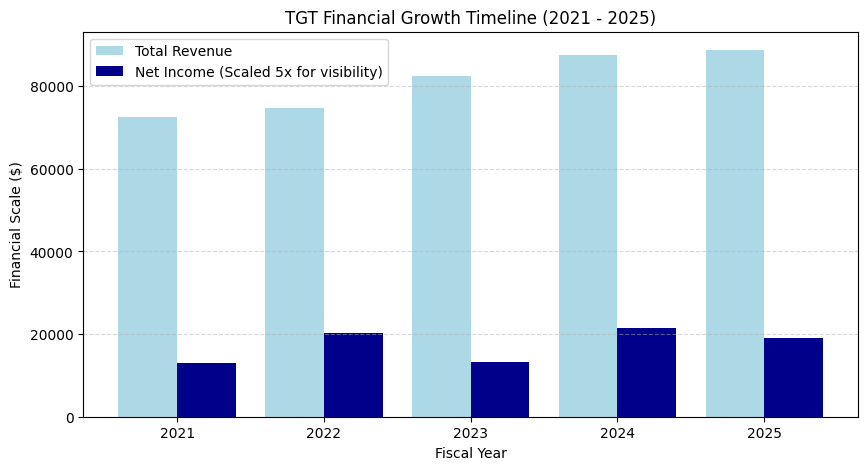

In [10]:
# ==============================================================================
# 10. BEGINNER LESSON: VISUALIZING REVENUE VS. NET INCOME WITH A BAR CHART
# ==============================================================================

# Pick a company to inspect over time (Target - TGT)
sample_ticker = "TGT"
chart_data = forensic_universe[forensic_universe['ticker'] == sample_ticker].sort_values('year')

# Create a clean, straightforward bar chart using matplotlib
plt.figure(figsize=(10, 5))

# Plot Revenue as light blue bars
plt.bar(chart_data['year'] - 0.2, chart_data['revenue'], width=0.4, label='Total Revenue', color='lightblue')

# Plot Net Income as dark blue bars right next to them
plt.bar(chart_data['year'] + 0.2, chart_data['net_income'] * 5, width=0.4, label='Net Income (Scaled 5x for visibility)', color='darkblue')

# Add labels, titles, and legends to our visual graph
plt.title(f"{sample_ticker} Financial Growth Timeline (2021 - 2025)")
plt.xlabel("Fiscal Year")
plt.ylabel("Financial Scale ($)")
plt.xticks(chart_data['year'])
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Display the chart safely inside Colab
plt.show()

In [11]:
# ==============================================================================
# 11. BEGINNER LESSON: SCREENING FOR FINANCIAL RISK (HIGH DEBT + LOW LIQUIDITY)
# ==============================================================================

# Let's search our 2025 database for companies matching risky stock indicators:
# Risk Rule 1: Debt to Equity ratio is greater than 1.5 (High Debt Leverage)
# Risk Rule 2: Current Ratio is less than 1.2 (Low Short-Term Liquid Runway)

high_debt_threshold = 1.5
low_liquidity_threshold = 1.2

risky_stocks_df = data_2025[
    (data_2025['debt_to_equity'] > high_debt_threshold) &
    (data_2025['current_ratio'] < low_liquidity_threshold)
]

print("=== FINANCIAL RUNWAY RISK REPORT (2025) ===")
if risky_stocks_df.empty:
    print("Good news! No companies in the retail sector cohort currently violate these safety risk rules.")
else:
    for index, row in risky_stocks_df.iterrows():
        print(f"⚠️ RISK ALERT: {row['ticker']}")
        print(f"   -> Debt to Equity: {row['debt_to_equity']:.2f}x (Target Limit: < {high_debt_threshold}x)")
        print(f"   -> Current Ratio : {row['current_ratio']:.2f}x (Target Limit: > {low_liquidity_threshold}x)")
        print("-" * 50)

=== FINANCIAL RUNWAY RISK REPORT (2025) ===
Good news! No companies in the retail sector cohort currently violate these safety risk rules.
